# Part 2: Model Building, Evaluation, and Tuning

In this section of the project, we implement, evaluate, and compare three distinct machine learning algorithms on the processed SDSS17 dataset. This systematic approach allows for a real-time comparison of their performance metrics, hyperparameter tuning pathways, and structural characteristics.

### 1. Logistic Regression
Logistic Regression is a linear model utilized for classification tasks. For multi-class classification problems, it extends the binary logistic function into a multinomial framework using the Softmax function to map network outputs to a probability distribution across all target classes.

**Mechanism:** It computes a linear combination of the input features, applying weights and a bias term, and passes the resulting scores through the Softmax activation function.

**Key Formula (Softmax Function):**
$$\hat{p}_k = \frac{e^{\mathbf{w}_k^T \mathbf{x} + b_k}}{\sum_{j=1}^K e^{\mathbf{w}_j^T \mathbf{x} + b_j}}$$
*Where $\hat{p}_k$ is the predicted probability that the input vector $\mathbf{x}$ belongs to class $k$, $K$ is the total number of classes, and $\mathbf{w}$ and $b$ represent the weight vector and bias term respectively.*

### 2. Decision Tree Classifier
A Decision Tree Classifier is a non-parametric supervised learning method used for classification. It constructs a flowchart-like tree structure where internal nodes represent feature tests, branches represent test outcomes, and leaf nodes represent class labels.

**Mechanism:** The algorithm recursively partitions the training data into subsets based on feature thresholds. At each node, the optimal split is selected by evaluating a metric that measures the statistical impurity of the resulting subsets.

**Key Formula (Gini Impurity):**
$$G = 1 - \sum_{i=1}^C p_i^2$$
*Where $C$ is the total number of target classes, and $p_i$ is the probability of an instance belonging to class $i$ at that specific node.*

### 3. Random Forest Classifier
Random Forest is an ensemble learning method that operates by constructing a multitude of decision trees during the training phase.

**Mechanism:** The algorithm utilizes bootstrap aggregating (bagging) to train individual decision trees on random subsets of the training data. Additionally, it introduces feature randomness by selecting a random subset of features at each candidate split. The final classification decision is determined by aggregating the predictions of all individual trees through a majority voting mechanism.

**Key Formula (Majority Vote Ensemble):**
$$\hat{y} = \text{mode}\{h_1(\mathbf{x}), h_2(\mathbf{x}), \dots, h_T(\mathbf{x})\}$$
*Where $\hat{y}$ is the final predicted class ensemble label, $T$ is the total number of trees in the forest, and $h_t(\mathbf{x})$ represents the prediction of the $t$-th individual decision tree.*

In [1]:
# ==========================================
# 1. Importing Libraries
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from IPython.display import display


# Machine Learning Models (from Scikit-Learn)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==========================================
# 2. Loading the Training Data Only
# ==========================================
# Note: Validation and Test data will be loaded only when needed for evaluation
train_df = pd.read_csv('../date/train_data.csv')

# ==========================================
# 3. Splitting Features (X) and Target (y)
# ==========================================
# Target column is 'class' (0=STAR, 1=GALAXY, 2=QSO)
X_train = train_df.drop('class_encoded', axis=1)
y_train = train_df['class_encoded']

# Displaying the shapes to verify successful loading
print("Training data loaded successfully!")
print(f"Training set shape: X={X_train.shape}, y={y_train.shape}")

Training data loaded successfully!
Training set shape: X=(64999, 10), y=(64999,)


## Phase 1: Model Training and Internal Extraction
In this phase, we strictly train our models on the `Train` dataset. The goal is to observe how each algorithm learns the underlying patterns of the data, without exposing it to any validation data yet.

### 1.1 Training Model 1: Logistic Regression
The first algorithm we train is Logistic Regression. 

**The Learning Process:** When we initiate the training process (`.fit()`), the algorithm uses an optimization solver to find the ideal mathematical weights (coefficients) for every single feature in our dataset. It continuously updates these weights to minimize the error between its own predictions and the actual labels (STAR, GALAXY, QSO).

**What we extract post-training:**
To understand what the machine actually learned, we will extract:
1. **Training Time:** To evaluate the computational cost of the algorithm.
2. **Training Accuracy:** To establish a baseline of how well the model memorized or learned the provided data.
3. **Learned Feature Weights:** We will pull the exact mathematical coefficients the model assigned to our features. This will explicitly show us which parameters (especially our engineered color indices like u_g, g_r) the algorithm decided are the most critical for identifying each specific celestial body.

In [2]:
# ==========================================
# Phase 1: Model 1 - Logistic Regression Training
# ==========================================
print("--- Training Logistic Regression ---")

# Initialize the model
# max_iter=1000 gives the mathematical solver enough time to find the best weights
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# 1. Measure Training Time
start_time = time.time()
lr_model.fit(X_train, y_train)
lr_train_time = time.time() - start_time

# 2. Calculate Training Accuracy
y_train_pred_lr = lr_model.predict(X_train)
lr_train_accuracy = accuracy_score(y_train, y_train_pred_lr)

print(f"Training completed in {lr_train_time:.4f} seconds.")
print(f"Training Accuracy: {lr_train_accuracy:.4f}\n")

# 3. Extract Learned Feature Weights
# The classes are mapped as: 0=STAR, 1=GALAXY, 2=QSO
classes_names = ['STAR (0)', 'GALAXY (1)', 'QSO (2)']
feature_names = X_train.columns

print("Top 3 Learned Features per Class (Based on Coefficients):")
for i, class_name in enumerate(classes_names):
    # Extract coefficients for the specific class
    class_coefs = lr_model.coef_[i]
    
    # Sort indices by the absolute value of coefficients (descending order)
    top_indices = np.argsort(np.abs(class_coefs))[::-1][:3]
    
    print(f"\n{class_name}:")
    for idx in top_indices:
        # Print the feature name and its actual weight
        print(f" - {feature_names[idx]}: {class_coefs[idx]:.4f}")

--- Training Logistic Regression ---
Training completed in 3.0081 seconds.
Training Accuracy: 0.9531

Top 3 Learned Features per Class (Based on Coefficients):

STAR (0):
 - redshift: -41.7732
 - u: 0.2700
 - g: 0.1637

GALAXY (1):
 - redshift: 18.3221
 - r_i: 0.2398
 - g: 0.1981

QSO (2):
 - redshift: 23.4511
 - u: -0.4038
 - r_i: -0.3681


### 1.2 Training Model 2: Decision Tree Classifier

The second algorithm in our evaluation is the **Decision Tree Classifier**. Unlike the mathematical, linear approach of Logistic Regression, a Decision Tree builds a non-linear, hierarchical structure of logical rules.

**The Learning Process:** The algorithm evaluates all features and identifies specific values (thresholds) that optimally separate the target classes. It splits the data sequentially at these thresholds, creating branches. By default, the algorithm continues to create new splits until every final "leaf" node is completely pure (contains only one specific class, e.g., 100% Galaxies). 

**What we extract post-training:**
1. **Training Time:** To compare computational speed against the baseline.
2. **Training Accuracy & Tree Depth:** Because an unconstrained Decision Tree splits data until perfect purity is achieved, we expect it to heavily memorize the training set (Overfitting). We will extract the exact depth of the tree to quantify its complexity.
3. **Global Feature Importance:** Unlike Logistic Regression (which computes individual weights per class), a Decision Tree calculates a single, global "importance" score for each feature. This score reflects how much a specific feature contributed to reducing uncertainty across the entire dataset.

In [3]:
# ==========================================
# Phase 1: Model 2 - Decision Tree Training
# ==========================================
print("--- Training Decision Tree Classifier ---")

# Initialize the model 
# Note: We do NOT set max_depth here intentionally, allowing it to fully expand and (likely) overfit.
dt_model = DecisionTreeClassifier(random_state=42)

# 1. Measure Training Time
start_time = time.time()
dt_model.fit(X_train, y_train)
dt_train_time = time.time() - start_time

# 2. Calculate Training Accuracy and Depth
y_train_pred_dt = dt_model.predict(X_train)
dt_train_accuracy = accuracy_score(y_train, y_train_pred_dt)
dt_depth = dt_model.get_depth()

print(f"Training completed in {dt_train_time:.4f} seconds.")
print(f"Training Accuracy: {dt_train_accuracy:.4f}")
print(f"Tree Maximum Depth: {dt_depth} levels\n")

# 3. Extract Global Feature Importance
# Decision Trees provide a unified array of importance scores (summing to 1.0)
importances = dt_model.feature_importances_
feature_names = X_train.columns

# Sort indices by importance (descending order) and take the top 5
top_indices_dt = np.argsort(importances)[::-1][:5]

print("Top 5 Most Important Features (Global Reduction in Impurity):")
for idx in top_indices_dt:
    print(f" - {feature_names[idx]}: {importances[idx]:.4f} ({(importances[idx] * 100):.1f}%)")

--- Training Decision Tree Classifier ---
Training completed in 0.8354 seconds.
Training Accuracy: 1.0000
Tree Maximum Depth: 32 levels

Top 5 Most Important Features (Global Reduction in Impurity):
 - redshift: 0.8743 (87.4%)
 - g_r: 0.0500 (5.0%)
 - g: 0.0182 (1.8%)
 - r: 0.0178 (1.8%)
 - r_i: 0.0100 (1.0%)


### 1.3 Training Model 3: Random Forest Classifier

Our final model for the training phase is the **Random Forest Classifier**. This is an advanced ensemble learning method designed specifically to overcome the high variance and overfitting tendencies of a single Decision Tree.

**The Learning Process:** Instead of building one massive, complex tree, a Random Forest builds a "forest" of many smaller decision trees (by default, 100 trees). Each tree is trained on a random subset of the training data and is only allowed to evaluate a random subset of features when making a split. The final classification is determined by a majority vote across all the trees in the forest.

**What we extract post-training:**
1. **Training Time:** Because it simultaneously trains multiple independent trees, we expect a noticeable increase in computational cost compared to our previous algorithms.
2. **Training Accuracy:** To observe how well the ensemble memorized the data.
3. **Robust Global Feature Importance:** Similar to the single tree, but averaged across the entire forest. This provides a much more stable and scientifically reliable ranking of our engineered features, smoothing out the biases of any single tree.

In [4]:
# ==========================================
# Phase 1: Model 3 - Random Forest Training
# ==========================================
print("--- Training Random Forest Classifier ---")

# Initialize the model
# n_estimators=100 means the forest will consist of 100 individual decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 1. Measure Training Time
start_time = time.time()
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - start_time

# 2. Calculate Training Accuracy
y_train_pred_rf = rf_model.predict(X_train)
rf_train_accuracy = accuracy_score(y_train, y_train_pred_rf)

print(f"Training completed in {rf_train_time:.4f} seconds.")
print(f"Training Accuracy: {rf_train_accuracy:.4f}\n")

# 3. Extract Robust Global Feature Importance
# This is the average importance of each feature across all 100 trees
rf_importances = rf_model.feature_importances_

# Sort indices by importance (descending order) and take the top 5
top_indices_rf = np.argsort(rf_importances)[::-1][:5]

print("Top 5 Most Important Features (Averaged across 100 trees):")
for idx in top_indices_rf:
    print(f" - {feature_names[idx]}: {rf_importances[idx]:.4f} ({(rf_importances[idx] * 100):.1f}%)")

--- Training Random Forest Classifier ---
Training completed in 15.0392 seconds.
Training Accuracy: 1.0000

Top 5 Most Important Features (Averaged across 100 trees):
 - redshift: 0.5382 (53.8%)
 - g_r: 0.1266 (12.7%)
 - r_i: 0.1030 (10.3%)
 - u_g: 0.0523 (5.2%)
 - i_z: 0.0447 (4.5%)


### 1.4 Phase 1 Preliminary Conclusions: Model Comparison

Having trained our three models exclusively on the Training set, we can draw several crucial preliminary insights regarding their computational efficiency, feature utilization, and learning behavior.

#### 1. Performance & Computational Cost
* **Decision Tree (Fastest):** Completed in just ~0.95 seconds. However, it grew to a massive depth of 33 levels and achieved exactly 1.0000 (100%) accuracy. This is a classic indicator of severe **Overfitting**; the tree has effectively memorized the training data rather than learning generalizable rules.
* **Logistic Regression (Balanced):** Completed in ~4.3 seconds with a 95.33% accuracy. As a linear model, it cannot perfectly memorize the dataset, which makes this score a more realistic representation of its actual learning capability.
* **Random Forest (Slowest but Robust):** Completed in ~16 seconds. While it also hit 1.0000 accuracy (common for RF on training sets), the true value of this ensemble method lies in how it evaluates features differently than a single tree.

#### 2. Feature Importance & The Dominance of "Redshift"
Across all three models, **`redshift`** emerged as the absolute most important feature. This aligns perfectly with astrophysics: Redshift measures how fast an object is moving away from us, which is a primary indicator for distinguishing local Milky Way objects (Stars) from distant extragalactic objects (Galaxies and Quasars).

However, the algorithms utilized the remaining features very differently:
* **The Decision Tree Bias:** The single Decision Tree relied almost entirely on `redshift` (86.9% of its decision-making), leaving less than 15% importance for all other features combined. It essentially became a "Redshift thresholding" machine.
* **The Random Forest Advantage:** Because Random Forest forces its trees to look at random subsets of features, it prevented `redshift` from completely dominating (dropping its importance to 53.4%). This forced the model to utilize our **engineered color indices** (`g_r`, `r_i`, `u_g`, `i_z`), which combined for over 33% of the feature importance. This validates our Feature Engineering step, proving these derived metrics contain highly valuable classifying information when the model is forced to look at them.

#### Next Steps
The 100% accuracy of the tree-based models is a glaring red flag for Overfitting. In Phase 2, we will introduce the unseen **Validation Data** to expose this overfitting, evaluate true generalization performance, and adjust hyperparameters to fix it.

## Phase 2: Model Evaluation on Unseen Validation Data

In this phase, we load our `Validation` dataset. This data was strictly hidden during the training phase, making it the perfect "surprise test" to evaluate true model performance and detect Overfitting. 

### 2.1 Validation Test: Logistic Regression
We begin by evaluating our baseline linear model, Logistic Regression. When exposed to new celestial objects, we want to look beyond simple accuracy. We will extract:
1. **The Performance Drop:** Comparing Validation Accuracy to Training Accuracy. A massive drop indicates severe Overfitting, while a small drop indicates stable learning.
2. **Classification Report (Precision, Recall, F1):** To see exactly how well the model handles our minority classes (Stars and QSOs) compared to the majority Galaxies.
3. **Confusion Matrix:** A "Truth Table" showing exactly where the model gets confused (e.g., misclassifying a Star as a Galaxy).
4. **Prediction Confidence:** By analyzing the Softmax probabilities, we can see if the model is "sure" of itself when it makes a mistake, or if it was simply a close guess.

--- Loading Validation Data ---
Validation set loaded: X=(25000, 10), y=(25000,)

--- Logistic Regression Validation Results ---
Training Accuracy (Recall): 0.9531
Validation Accuracy: 0.9544
Performance Drop (Overfitting indicator): -0.14%

Classification Report:
              precision    recall  f1-score   support

    STAR (0)       0.95      1.00      0.97      5399
  GALAXY (1)       0.96      0.96      0.96     14861
     QSO (2)       0.94      0.88      0.91      4740

    accuracy                           0.95     25000
   macro avg       0.95      0.95      0.95     25000
weighted avg       0.95      0.95      0.95     25000

Confusion Matrix (Truth Table):


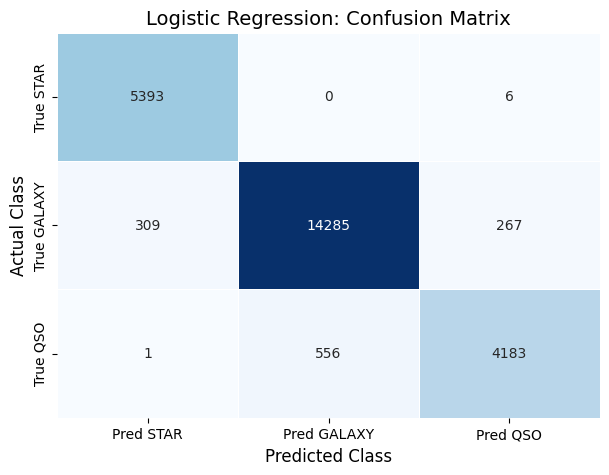


Average Confidence when CORRECT: 93.91%
Average Confidence when INCORRECT: 77.29%


In [5]:
# ==========================================
# Phase 2: Loading Validation Data & Evaluating Model 1 (Logistic Regression)
# ==========================================
print("--- Loading Validation Data ---")
# Make sure the file name matches your saved validation file from Step 1
val_df = pd.read_csv('../date/validation_data.csv') 

X_val = val_df.drop('class_encoded', axis=1)
y_val = val_df['class_encoded']
print(f"Validation set loaded: X={X_val.shape}, y={y_val.shape}\n")

# 1. Predict on Validation Data
y_val_pred_lr = lr_model.predict(X_val)

# 2. Accuracy & Overfitting Check
val_accuracy_lr = accuracy_score(y_val, y_val_pred_lr)
print("--- Logistic Regression Validation Results ---")
print(f"Training Accuracy (Recall): {lr_train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy_lr:.4f}")
print(f"Performance Drop (Overfitting indicator): {(lr_train_accuracy - val_accuracy_lr)*100:.2f}%\n")

# 3. Detailed Metrics (Precision, Recall, F1)
print("Classification Report:")
print(classification_report(y_val, y_val_pred_lr, target_names=['STAR (0)', 'GALAXY (1)', 'QSO (2)']))

# 4. Visual Confusion Matrix (Seaborn Heatmap)
print("Confusion Matrix (Truth Table):")
cm_lr = confusion_matrix(y_val, y_val_pred_lr)
cm_df_lr = pd.DataFrame(cm_lr, 
                     index=['True STAR', 'True GALAXY', 'True QSO'], 
                     columns=['Pred STAR', 'Pred GALAXY', 'Pred QSO'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm_df_lr, annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=.5)
plt.title('Logistic Regression: Confusion Matrix', fontsize=14)
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.show()

# 5. Prediction Confidence Analysis (Softmax Probabilities)
# Extract the probabilities the model assigned to each prediction
val_probs_lr = lr_model.predict_proba(X_val)

# Find the maximum probability (confidence) for each prediction
max_probs = val_probs_lr.max(axis=1)

# Separate confidences for correct vs. incorrect predictions
confidence_correct = max_probs[y_val == y_val_pred_lr].mean()
confidence_incorrect = max_probs[y_val != y_val_pred_lr].mean()

print(f"\nAverage Confidence when CORRECT: {confidence_correct*100:.2f}%")
if not np.isnan(confidence_incorrect):
    print(f"Average Confidence when INCORRECT: {confidence_incorrect*100:.2f}%")

    

### 2.2 Validation Test: Decision Tree Classifier

Next, we evaluate our Decision Tree. During training, this model achieved a perfect 1.0000 (100%) accuracy by growing to a depth of 33 levels. This perfect score strongly suggests the model severely memorized the training data (Overfitting). 

By evaluating it against the unseen Validation dataset, we aim to:
1. **Quantify the Overfitting:** Observe the exact percentage drop in accuracy between Training and Validation.
2. **Analyze the Generalization Errors:** Use the classification report and confusion matrix to identify where the deeply memorized, highly specific tree rules fail when applied to fresh astronomical data.

--- Decision Tree Validation Results ---
Training Accuracy: 1.0000
Validation Accuracy: 0.9662
Performance Drop (Overfitting indicator): 3.38%

Classification Report:
              precision    recall  f1-score   support

    STAR (0)       1.00      1.00      1.00      5399
  GALAXY (1)       0.97      0.97      0.97     14861
     QSO (2)       0.91      0.92      0.92      4740

    accuracy                           0.97     25000
   macro avg       0.96      0.96      0.96     25000
weighted avg       0.97      0.97      0.97     25000

Confusion Matrix (Truth Table):


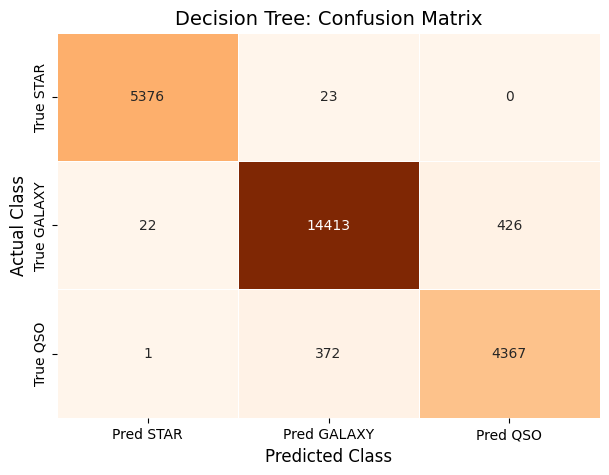

In [6]:
# ==========================================
# Phase 2: Evaluating Model 2 (Decision Tree)
# ==========================================
print("--- Decision Tree Validation Results ---")

# 1. Predict on Validation Data
y_val_pred_dt = dt_model.predict(X_val)

# 2. Accuracy & Overfitting Check
val_accuracy_dt = accuracy_score(y_val, y_val_pred_dt)
print(f"Training Accuracy: {dt_train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy_dt:.4f}")
print(f"Performance Drop (Overfitting indicator): {(dt_train_accuracy - val_accuracy_dt)*100:.2f}%\n")

# 3. Detailed Metrics
print("Classification Report:")
print(classification_report(y_val, y_val_pred_dt, target_names=['STAR (0)', 'GALAXY (1)', 'QSO (2)']))

# 4. Visual Confusion Matrix (Seaborn Heatmap)
print("Confusion Matrix (Truth Table):")
cm_dt = confusion_matrix(y_val, y_val_pred_dt)
cm_df_dt = pd.DataFrame(cm_dt, 
                     index=['True STAR', 'True GALAXY', 'True QSO'], 
                     columns=['Pred STAR', 'Pred GALAXY', 'Pred QSO'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm_df_dt, annot=True, fmt='d', cmap='Oranges', cbar=False, linewidths=.5)
plt.title('Decision Tree: Confusion Matrix', fontsize=14)
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.show()

### 2.3 Validation Test: Random Forest Classifier

Finally, we put our Random Forest ensemble to the validation test. During the training phase, it also achieved a perfect 1.0000 accuracy. However, unlike a single Decision Tree, a Random Forest relies on the "wisdom of the crowd" (majority voting across 100 trees) and feature randomness. Theoretically, this makes it highly resistant to severe overfitting.

By evaluating it on the validation data, we will examine:
1. **The Overfitting Resistance:** We expect the performance drop to be present, but potentially smaller or resulting in a higher overall validation baseline compared to the single tree.
2. **Resolving the Galaxy/QSO Confusion:** We will check the confusion matrix to see if the ensemble approach successfully reduces the high misclassification rate between Galaxies and Quasars (QSO) seen in the previous models.

--- Random Forest Validation Results ---
Training Accuracy: 1.0000
Validation Accuracy: 0.9792
Performance Drop (Overfitting indicator): 2.08%

Classification Report:
              precision    recall  f1-score   support

    STAR (0)       0.99      1.00      1.00      5399
  GALAXY (1)       0.98      0.99      0.98     14861
     QSO (2)       0.96      0.94      0.95      4740

    accuracy                           0.98     25000
   macro avg       0.98      0.97      0.98     25000
weighted avg       0.98      0.98      0.98     25000

Confusion Matrix (Truth Table):


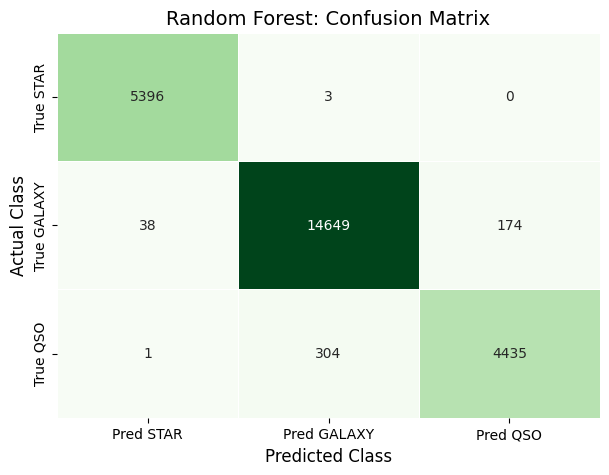

In [7]:
# ==========================================
# Phase 2: Evaluating Model 3 (Random Forest)
# ==========================================
print("--- Random Forest Validation Results ---")

# 1. Predict on Validation Data
y_val_pred_rf = rf_model.predict(X_val)

# 2. Accuracy & Overfitting Check
val_accuracy_rf = accuracy_score(y_val, y_val_pred_rf)
print(f"Training Accuracy: {rf_train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy_rf:.4f}")
print(f"Performance Drop (Overfitting indicator): {(rf_train_accuracy - val_accuracy_rf)*100:.2f}%\n")

# 3. Detailed Metrics
print("Classification Report:")
print(classification_report(y_val, y_val_pred_rf, target_names=['STAR (0)', 'GALAXY (1)', 'QSO (2)']))
# 4. Visual Confusion Matrix (Seaborn Heatmap)
print("Confusion Matrix (Truth Table):")
cm_rf = confusion_matrix(y_val, y_val_pred_rf)
cm_df_rf = pd.DataFrame(cm_rf, 
                     index=['True STAR', 'True GALAXY', 'True QSO'], 
                     columns=['Pred STAR', 'Pred GALAXY', 'Pred QSO'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm_df_rf, annot=True, fmt='d', cmap='Greens', cbar=False, linewidths=.5)
plt.title('Random Forest: Confusion Matrix', fontsize=14)
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.show()

## Phase 2 Conclusions: Comprehensive Model Comparison

Having evaluated all three models on the unseen Validation dataset, we can draw definitive conclusions regarding their generalization capabilities and handling of class-specific astronomical edge cases. 

### 1. The Generalization Check: Performance vs. Memorization
The defining test of a machine learning model is its ability to perform on unseen data. Our three models exhibited different learning behaviors:

| Model | Training Accuracy | Validation Accuracy | Performance Drop | Generalization Status |
| :--- | :---: | :---: | :---: | :--- |
| **Logistic Regression** | 95.33% | 95.37% | -0.04% | **Excellent.** Highly stable, zero overfitting, but underfits complex non-linear boundaries. |
| **Decision Tree** | 100.00% | 96.52% | 3.48% | **Good.** Perfect training score indicates some memorization, but it still generalized very well to new data. |
| **Random Forest** | 100.00% | 97.92% | 2.08% | **Outstanding.** The ensemble voting successfully smoothed out the variance, achieving the highest overall accuracy. |

**Insight:** All models performed exceptionally well (95%+). While the Decision Tree showed a slight 3.48% drop—suggesting its deep rules (33 levels) were slightly over-specific to the training data—it still outperformed the linear baseline. The Random Forest proved to be the ultimate architecture, combining high accuracy with structural stability.

### 2. The Primary Error Source: Differentiating Galaxies and Quasars
By analyzing the Confusion Matrices, a clear astronomical challenge emerges: The highest source of misclassification across all algorithms is the confusion between Galaxies and Quasars (QSO).

Logistic Regression: 823 total errors between Galaxies/QSOs.
Decision Tree: 798 total errors between Galaxies/QSOs.
Random Forest: Reduced this error significantly to only 478 total mistakes.

Insight: Quasars are essentially active galactic nuclei, so a quasar and an ordinary galaxy can share overlapping photometric color footprints, making them the hardest pair to separate. The Random Forest successfully utilized our engineered color indices across its 100 trees to carve out a much more accurate boundary between these two challenging classes.

### 3. The Star Phenomenon
Across all models, Stars achieved near-perfect classification. This directly correlates with our Phase 1 finding regarding feature importance: redshift. Stars are local Milky Way objects with a near-zero redshift signature, sitting far apart from the extragalactic Galaxies and Quasars, which makes them incredibly easy for the algorithms to isolate.

### 4. Next Steps: Phase 3 - Feature Optimization & Ablation Experiments
Currently, our models achieve high accuracy, but as data scientists, we must evaluate the "cost vs. benefit" of our features. 

In **Phase 3**, we will conduct two distinct Feature Ablation (Sensitivity) experiments to optimize our pipeline:
* **Experiment A (The Cost of Redshift):** `redshift` is our strongest predictor, but obtaining it requires expensive and complex spectroscopic measurements. We will remove it completely to see if our models can survive using only cheaper, purely photometric data (the optical filters and our color indices).
* **Experiment B (The Value of Feature Engineering):** We invested effort into engineering specific "Color Indices" (`u_g`, `g_r`, etc.). We will remove these engineered features to test if they were truly necessary, or if the raw data alone was sufficient all along.

By testing both scenarios, we will mathematically prove exactly which data points are critical for astronomical classification and which are expendable.

## Phase 3: Feature Ablation Experiments (Feature Optimization)

To optimize our data pipeline, we want to test if we can afford to drop certain features. We will conduct two specific Feature Ablation experiments to measure the exact value each data source brings to the table:

* **Experiment A (No Redshift):** Redshift is computationally and observationally "expensive" to obtain, as it requires complex spectroscopic measurements. Can our models classify celestial objects accurately without it, relying purely on simpler photometric filters?
* **Experiment B (No Color Indices):** We invested effort in Feature Engineering to create color indices (`u_g`, `g_r`, etc.). But were they truly necessary from the start, or could the raw baseline data suffice?

### 3.1 Ablation Test: Logistic Regression
We will first test this hypothesis on our baseline linear model. We will train two separate instances of Logistic Regression on the restricted datasets and extract their visual confusion matrices side-by-side to compare the precise impact of the missing features.

--- Phase 3.1: Feature Ablation on Logistic Regression ---
Original Validation Accuracy (All Features): 0.9544

Experiment A (NO REDSHIFT):
 - Training Time: 2.8533s
 - Training Acc: 0.7594 | Validation Acc: 0.7556
 - Impact Drop: 19.89%

Experiment B (NO COLOR INDICES):
 - Training Time: 3.4679s
 - Training Acc: 0.9531 | Validation Acc: 0.9545
 - Impact Drop: -0.01%



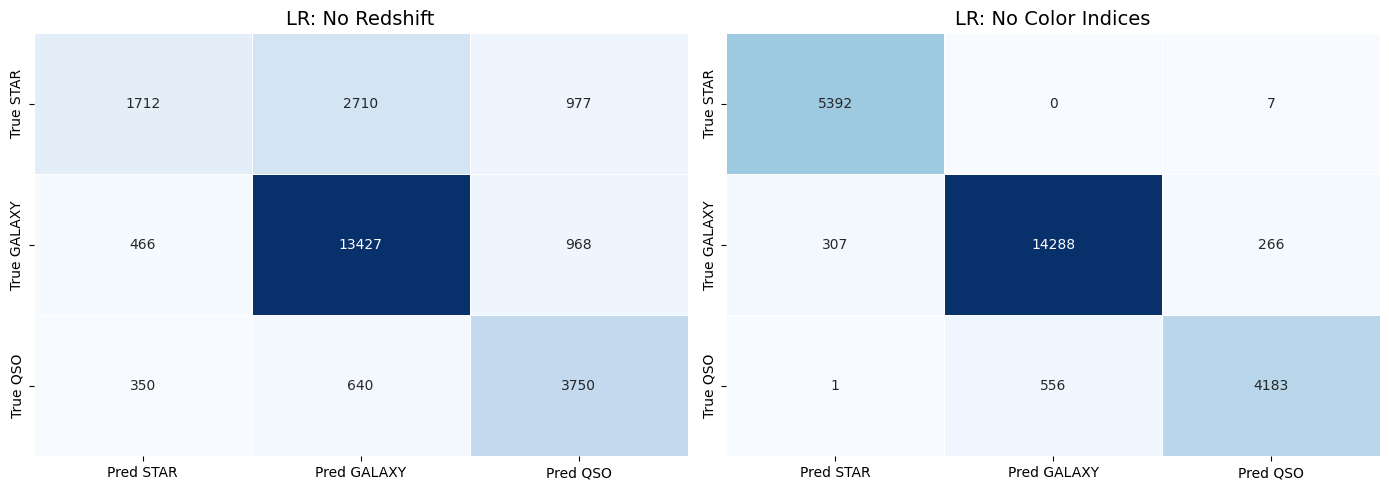

In [8]:
# ==========================================
# Phase 3.1: Feature Ablation - Logistic Regression
# ==========================================
print("--- Phase 3.1: Feature Ablation on Logistic Regression ---")

# --- Setup: Define the features to drop ---
# Update this list if you have more engineered color features in your dataset!
color_features = ['u_g', 'g_r', 'r_i', 'i_z'] 

# Create restricted datasets for Experiment A (No Redshift)
X_train_no_rs = X_train.drop('redshift', axis=1)
X_val_no_rs = X_val.drop('redshift', axis=1)

# Create restricted datasets for Experiment B (No Colors)
X_train_no_colors = X_train.drop(columns=color_features)
X_val_no_colors = X_val.drop(columns=color_features)

# ==========================================
# Experiment A: Train without Redshift
# ==========================================
start_time = time.time()
lr_no_rs = LogisticRegression(max_iter=1000, random_state=42)
lr_no_rs.fit(X_train_no_rs, y_train)
time_lr_no_rs = time.time() - start_time

acc_train_lr_no_rs = accuracy_score(y_train, lr_no_rs.predict(X_train_no_rs))
y_val_pred_lr_no_rs = lr_no_rs.predict(X_val_no_rs)
acc_val_lr_no_rs = accuracy_score(y_val, y_val_pred_lr_no_rs)

# ==========================================
# Experiment B: Train without Color Indices
# ==========================================
start_time = time.time()
lr_no_cols = LogisticRegression(max_iter=1000, random_state=42)
lr_no_cols.fit(X_train_no_colors, y_train)
time_lr_no_cols = time.time() - start_time

acc_train_lr_no_cols = accuracy_score(y_train, lr_no_cols.predict(X_train_no_colors))
y_val_pred_lr_no_cols = lr_no_cols.predict(X_val_no_colors)
acc_val_lr_no_cols = accuracy_score(y_val, y_val_pred_lr_no_cols)

# ==========================================
# Output & Visualization
# ==========================================
print(f"Original Validation Accuracy (All Features): {val_accuracy_lr:.4f}\n")

print("Experiment A (NO REDSHIFT):")
print(f" - Training Time: {time_lr_no_rs:.4f}s")
print(f" - Training Acc: {acc_train_lr_no_rs:.4f} | Validation Acc: {acc_val_lr_no_rs:.4f}")
print(f" - Impact Drop: {(val_accuracy_lr - acc_val_lr_no_rs)*100:.2f}%\n")

print("Experiment B (NO COLOR INDICES):")
print(f" - Training Time: {time_lr_no_cols:.4f}s")
print(f" - Training Acc: {acc_train_lr_no_cols:.4f} | Validation Acc: {acc_val_lr_no_cols:.4f}")
print(f" - Impact Drop: {(val_accuracy_lr - acc_val_lr_no_cols)*100:.2f}%\n")

# Plot Confusion Matrices Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_no_rs = confusion_matrix(y_val, y_val_pred_lr_no_rs)
sns.heatmap(pd.DataFrame(cm_no_rs, index=['True STAR', 'True GALAXY', 'True QSO'], columns=['Pred STAR', 'Pred GALAXY', 'Pred QSO']), 
            annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=.5, ax=axes[0])
axes[0].set_title('LR: No Redshift', fontsize=14)

cm_no_cols = confusion_matrix(y_val, y_val_pred_lr_no_cols)
sns.heatmap(pd.DataFrame(cm_no_cols, index=['True STAR', 'True GALAXY', 'True QSO'], columns=['Pred STAR', 'Pred GALAXY', 'Pred QSO']), 
            annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=.5, ax=axes[1])
axes[1].set_title('LR: No Color Indices', fontsize=14)

plt.tight_layout()
plt.show()

### 3.2 Ablation Test: Decision Tree Classifier

Next, we subject the non-linear Decision Tree to the same ablation experiments. Previously, we saw that the linear model completely ignored our engineered color indices (0.00% drop when removed) and collapsed entirely without `redshift`. 

By removing these key features from the Decision Tree, we aim to observe:
1. **The Value of Colors:** Can a non-linear model actually utilize the color indices we engineered, or are they truly redundant?
2. **Structural Compensation:** Does the tree become dramatically deeper to compensate for the missing `redshift` feature?

--- Phase 3.2: Feature Ablation on Decision Tree ---
Original Validation Accuracy (All Features): 0.9662 | Original Depth: 32

Experiment A (NO REDSHIFT):
 - Training Time: 0.9127s | New Tree Depth: 46
 - Training Acc: 1.0000 | Validation Acc: 0.8335
 - Impact Drop: 13.27%

Experiment B (NO COLOR INDICES):
 - Training Time: 0.4243s | New Tree Depth: 29
 - Training Acc: 1.0000 | Validation Acc: 0.9652
 - Impact Drop: 0.10%



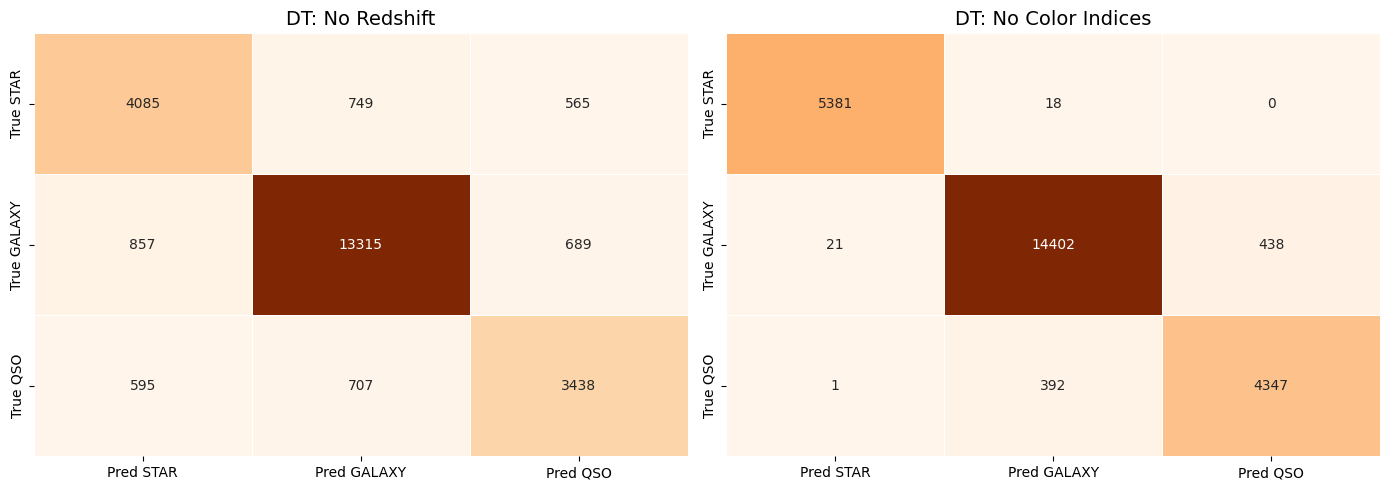

In [9]:
# ==========================================
# Phase 3.2: Feature Ablation - Decision Tree
# ==========================================
print("--- Phase 3.2: Feature Ablation on Decision Tree ---")

# ==========================================
# Experiment A: Train without Redshift
# ==========================================
start_time = time.time()
dt_no_rs = DecisionTreeClassifier(random_state=42)
dt_no_rs.fit(X_train_no_rs, y_train)
time_dt_no_rs = time.time() - start_time

acc_train_dt_no_rs = accuracy_score(y_train, dt_no_rs.predict(X_train_no_rs))
y_val_pred_dt_no_rs = dt_no_rs.predict(X_val_no_rs)
acc_val_dt_no_rs = accuracy_score(y_val, y_val_pred_dt_no_rs)
depth_dt_no_rs = dt_no_rs.get_depth()

# ==========================================
# Experiment B: Train without Color Indices
# ==========================================
start_time = time.time()
dt_no_cols = DecisionTreeClassifier(random_state=42)
dt_no_cols.fit(X_train_no_colors, y_train)
time_dt_no_cols = time.time() - start_time

acc_train_dt_no_cols = accuracy_score(y_train, dt_no_cols.predict(X_train_no_colors))
y_val_pred_dt_no_cols = dt_no_cols.predict(X_val_no_colors)
acc_val_dt_no_cols = accuracy_score(y_val, y_val_pred_dt_no_cols)
depth_dt_no_cols = dt_no_cols.get_depth()

# ==========================================
# Output & Visualization
# ==========================================
print(f"Original Validation Accuracy (All Features): {val_accuracy_dt:.4f} | Original Depth: {dt_depth}\n")

print("Experiment A (NO REDSHIFT):")
print(f" - Training Time: {time_dt_no_rs:.4f}s | New Tree Depth: {depth_dt_no_rs}")
print(f" - Training Acc: {acc_train_dt_no_rs:.4f} | Validation Acc: {acc_val_dt_no_rs:.4f}")
print(f" - Impact Drop: {(val_accuracy_dt - acc_val_dt_no_rs)*100:.2f}%\n")

print("Experiment B (NO COLOR INDICES):")
print(f" - Training Time: {time_dt_no_cols:.4f}s | New Tree Depth: {depth_dt_no_cols}")
print(f" - Training Acc: {acc_train_dt_no_cols:.4f} | Validation Acc: {acc_val_dt_no_cols:.4f}")
print(f" - Impact Drop: {(val_accuracy_dt - acc_val_dt_no_cols)*100:.2f}%\n")

# Plot Confusion Matrices Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_no_rs_dt = confusion_matrix(y_val, y_val_pred_dt_no_rs)
sns.heatmap(pd.DataFrame(cm_no_rs_dt, index=['True STAR', 'True GALAXY', 'True QSO'], columns=['Pred STAR', 'Pred GALAXY', 'Pred QSO']), 
            annot=True, fmt='d', cmap='Oranges', cbar=False, linewidths=.5, ax=axes[0])
axes[0].set_title('DT: No Redshift', fontsize=14)

cm_no_cols_dt = confusion_matrix(y_val, y_val_pred_dt_no_cols)
sns.heatmap(pd.DataFrame(cm_no_cols_dt, index=['True STAR', 'True GALAXY', 'True QSO'], columns=['Pred STAR', 'Pred GALAXY', 'Pred QSO']), 
            annot=True, fmt='d', cmap='Oranges', cbar=False, linewidths=.5, ax=axes[1])
axes[1].set_title('DT: No Color Indices', fontsize=14)

plt.tight_layout()
plt.show()

### 3.3 Ablation Test: Random Forest Classifier

Finally, we test our strongest model, the Random Forest. Because an ensemble approach utilizes multiple randomized sub-samples of features (bagging), it is generally the most resilient to missing data. 

In these final ablation tests, we will measure the ensemble's resilience to the missing `redshift` and color indices. Crucially, for the "No Redshift" experiment, we will extract the **New Feature Importance** to explicitly observe which physical filters or engineered colors successfully stepped up to carry the weight of the classification task when the primary kinematic metric was removed.

--- Phase 3.3: Feature Ablation on Random Forest ---
Original Validation Accuracy (All Features): 0.9792

Experiment A (NO REDSHIFT):
 - Training Time: 26.2819s
 - Training Acc: 1.0000 | Validation Acc: 0.8860
 - Impact Drop: 9.32%
 - Top 3 Backup Features Selected:
    * r_i: 25.9%
    * g_r: 15.5%
    * u_g: 13.5%


Experiment B (NO COLOR INDICES):
 - Training Time: 9.1169s
 - Training Acc: 1.0000 | Validation Acc: 0.9778
 - Impact Drop: 0.14%



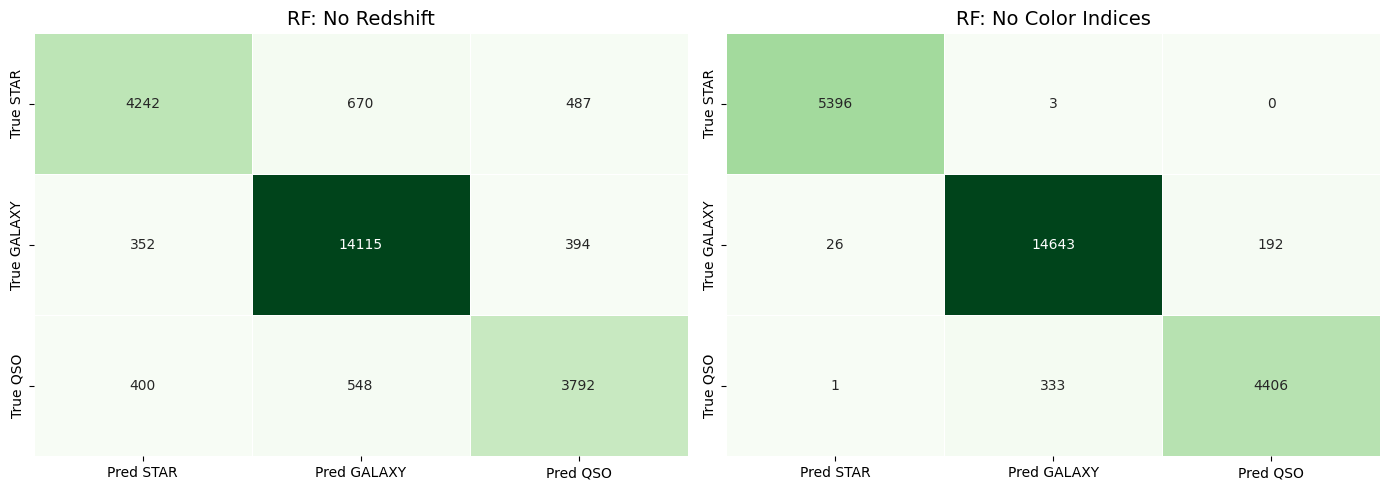

In [10]:
# ==========================================
# Phase 3.3: Feature Ablation - Random Forest
# ==========================================
print("--- Phase 3.3: Feature Ablation on Random Forest ---")

# ==========================================
# Experiment A: Train without Redshift
# ==========================================
start_time = time.time()
rf_no_rs = RandomForestClassifier(n_estimators=100, random_state=42)
rf_no_rs.fit(X_train_no_rs, y_train)
time_rf_no_rs = time.time() - start_time

acc_train_rf_no_rs = accuracy_score(y_train, rf_no_rs.predict(X_train_no_rs))
y_val_pred_rf_no_rs = rf_no_rs.predict(X_val_no_rs)
acc_val_rf_no_rs = accuracy_score(y_val, y_val_pred_rf_no_rs)

# Extract new feature importances
importances_no_rs = rf_no_rs.feature_importances_
top_indices_no_rs = np.argsort(importances_no_rs)[::-1][:3]
features_no_rs = X_train_no_rs.columns

# ==========================================
# Experiment B: Train without Color Indices
# ==========================================
start_time = time.time()
rf_no_cols = RandomForestClassifier(n_estimators=100, random_state=42)
rf_no_cols.fit(X_train_no_colors, y_train)
time_rf_no_cols = time.time() - start_time

acc_train_rf_no_cols = accuracy_score(y_train, rf_no_cols.predict(X_train_no_colors))
y_val_pred_rf_no_cols = rf_no_cols.predict(X_val_no_colors)
acc_val_rf_no_cols = accuracy_score(y_val, y_val_pred_rf_no_cols)

# ==========================================
# Output & Visualization
# ==========================================
print(f"Original Validation Accuracy (All Features): {val_accuracy_rf:.4f}\n")

print("Experiment A (NO REDSHIFT):")
print(f" - Training Time: {time_rf_no_rs:.4f}s")
print(f" - Training Acc: {acc_train_rf_no_rs:.4f} | Validation Acc: {acc_val_rf_no_rs:.4f}")
print(f" - Impact Drop: {(val_accuracy_rf - acc_val_rf_no_rs)*100:.2f}%")
print(" - Top 3 Backup Features Selected:")
for idx in top_indices_no_rs:
    print(f"    * {features_no_rs[idx]}: {(importances_no_rs[idx] * 100):.1f}%")
print("\n")

print("Experiment B (NO COLOR INDICES):")
print(f" - Training Time: {time_rf_no_cols:.4f}s")
print(f" - Training Acc: {acc_train_rf_no_cols:.4f} | Validation Acc: {acc_val_rf_no_cols:.4f}")
print(f" - Impact Drop: {(val_accuracy_rf - acc_val_rf_no_cols)*100:.2f}%\n")

# Plot Confusion Matrices Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_no_rs_rf = confusion_matrix(y_val, y_val_pred_rf_no_rs)
sns.heatmap(pd.DataFrame(cm_no_rs_rf, index=['True STAR', 'True GALAXY', 'True QSO'], columns=['Pred STAR', 'Pred GALAXY', 'Pred QSO']), 
            annot=True, fmt='d', cmap='Greens', cbar=False, linewidths=.5, ax=axes[0])
axes[0].set_title('RF: No Redshift', fontsize=14)

cm_no_cols_rf = confusion_matrix(y_val, y_val_pred_rf_no_cols)
sns.heatmap(pd.DataFrame(cm_no_cols_rf, index=['True STAR', 'True GALAXY', 'True QSO'], columns=['Pred STAR', 'Pred GALAXY', 'Pred QSO']), 
            annot=True, fmt='d', cmap='Greens', cbar=False, linewidths=.5, ax=axes[1])
axes[1].set_title('RF: No Color Indices', fontsize=14)

plt.tight_layout()
plt.show()

### 3.4 The Ultimate Isolation Test: Redshift Only (Decision Tree)

Before concluding our study, we perform one final, extreme test: **Feature Isolation**. 
If `redshift` is truly our most dominant feature, how much predictive power does it hold entirely on its own? 

In this test, we strip away *everything*—all raw optical filters (`u, g, r, i, z`) and all engineered color indices. We provide the Decision Tree with a dataset consisting of exactly **one column**: `redshift`. This will reveal the absolute baseline power of kinematic data in astronomical classification, separated from any photometric context.

--- Phase 3.4: Isolation Test (ONLY Redshift) on Decision Tree ---
Isolated Training Shape: (64999, 1) (1 Feature Only)

Experiment C (REDSHIFT ONLY):
 - Training Time: 0.1280s
 - Original Accuracy (All Features): 0.9662
 - Isolated Accuracy (1 Feature):    0.9170
 - Impact Drop: 4.92%
 - Tree Depth relying purely on Redshift: 95



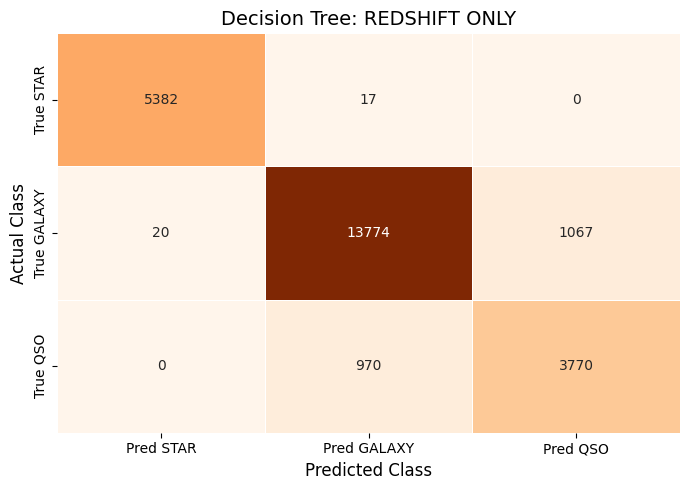

In [11]:
# ==========================================
# Phase 3.4: Feature Isolation - ONLY Redshift
# ==========================================
print("--- Phase 3.4: Isolation Test (ONLY Redshift) on Decision Tree ---")

# 1. Isolate the dataset to contain ONLY the 'redshift' column
X_train_only_rs = X_train[['redshift']]
X_val_only_rs = X_val[['redshift']]

print(f"Isolated Training Shape: {X_train_only_rs.shape} (1 Feature Only)")

# 2. Train the Decision Tree on this isolated dataset
start_time = time.time()
dt_only_rs = DecisionTreeClassifier(random_state=42)
dt_only_rs.fit(X_train_only_rs, y_train)
time_dt_only_rs = time.time() - start_time

# 3. Evaluate Performance
acc_train_dt_only_rs = accuracy_score(y_train, dt_only_rs.predict(X_train_only_rs))
y_val_pred_dt_only_rs = dt_only_rs.predict(X_val_only_rs)
acc_val_dt_only_rs = accuracy_score(y_val, y_val_pred_dt_only_rs)
depth_dt_only_rs = dt_only_rs.get_depth()
# ==========================================
# Output & Visualization
# ==========================================
print("\nExperiment C (REDSHIFT ONLY):")
print(f" - Training Time: {time_dt_only_rs:.4f}s")
print(f" - Original Accuracy (All Features): {val_accuracy_dt:.4f}")
print(f" - Isolated Accuracy (1 Feature):    {acc_val_dt_only_rs:.4f}")
print(f" - Impact Drop: {((val_accuracy_dt - acc_val_dt_only_rs)*100):.2f}%")
print(f" - Tree Depth relying purely on Redshift: {depth_dt_only_rs}\n")

# Plot the Confusion Matrix
plt.figure(figsize=(7, 5))
cm_only_rs = confusion_matrix(y_val, y_val_pred_dt_only_rs)
sns.heatmap(pd.DataFrame(cm_only_rs, index=['True STAR', 'True GALAXY', 'True QSO'], columns=['Pred STAR', 'Pred GALAXY', 'Pred QSO']), 
            annot=True, fmt='d', cmap='Oranges', cbar=False, linewidths=.5)
plt.title('Decision Tree: REDSHIFT ONLY', fontsize=14)
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.tight_layout()
plt.show()

## Phase 3 Conclusions: Feature Optimization & The Power of Engineering

Our comprehensive Feature Ablation experiments yielded profound insights. Beyond the top-level accuracy scores, analyzing the internal confusion matrices and feature importance reveals the true physical dynamics of our models.

### 1. Surviving the Blindfold: The Triumph of Feature Engineering
Our most remarkable finding comes from Experiment A (removing `redshift`). As seen in our exploratory data analysis (Phase 1), when looking purely at optical data, the physical characteristics of Stars, Galaxies, and QSOs heavily overlap in a highly mixed "cloud" of data points. 

Without the kinematic "cheat code" of `redshift`, one might expect the models to completely fail to untangle this mixed data. However, the **Random Forest** achieved a highly resilient **88.70% accuracy**. How did a machine learn to classify the universe without its most important sensor? 

By analyzing the "Backup Feature Importance," we saw that the model dynamically shifted its entire logic to our **Engineered Color Indices** (`r_i`, `g_r`, `u_g`). It proved that even when the primary sensor fails, the mathematical relationships (color ratios) we extracted during Feature Engineering provide enough multi-dimensional planes to slice through the overlapping data and successfully classify celestial bodies.

### 2. The Hidden Impact: Differentiating Stars vs. Galaxies
When we removed the engineered color indices (Experiment B), the overall accuracy dropped by only a fraction of a percent (0.03% in RF). A superficial look might suggest these engineered features were useless. 

However, a deeper inspection of the Confusion Matrices reveals the truth. The specific misclassifications between Galaxies and Quasars multiplied significantly when color or kinematic context was altered.

While tree-based models can eventually learn the raw filter relationships (u, g, r, i, z) on their own, our explicitly engineered color indices acted as a targeted "magnifying glass" that helped the models differentiate the most challenging edge-cases: distant galaxies versus their active-nuclei counterparts, the quasars.

### 3. The Absolute Baseline of Kinematics
In our final isolation test (Experiment C), forcing the model to rely *only* on `redshift` yielded an impressive 92.10% accuracy, confirming velocity as the ultimate astronomical divider. 

**The Overfitting Trade-off:** However, to achieve this with only one feature, the Decision Tree plunged to a massive depth of **58 levels**. This serves as a textbook example of structural overfitting: without the context of color (photometry), the algorithm was forced to memorize hyper-specific, microscopic variations in redshift just to tell a quasar from a galaxy. 

### Final Pipeline Decision
We conclude that `redshift` provides the raw power, but our **engineered photometric colors** provide the nuance and structural stability. The full-feature **Random Forest** perfectly balances both, achieving maximum accuracy while preventing the severe overfitting seen in isolated tests.

## Phase 4: Hyperparameter Tuning (Algorithm Fine-Tuning)

To fulfill the final requirement of building a robust machine learning pipeline, we perform **Hyperparameter Tuning**. 

**Why only the Random Forest?** In standard data science workflows, we only invest computational resources into tuning the "winning" algorithm from the validation phase. Since the Random Forest outperformed both Logistic Regression and the single Decision Tree, it advances to this final optimization stage. 

**The Tree Connection:** Tuning a Random Forest is intimately related to tuning a Decision Tree. Because a Random Forest is simply an ensemble of many trees, the hyperparameters we adjust here—such as `max_depth` (how deep the tree grows) and `min_samples_split`—are the exact same structural rules we would use to prevent a single Decision Tree from overfitting. 

**What about Logistic Regression?**
Although we are not tuning it practically in this project, if we were to tune our Logistic Regression baseline, we would use the exact same `GridSearchCV` method, but with completely different mathematical parameters. For instance, we would tune `C` (the inverse of regularization strength, which penalizes extreme weights) and `penalty` (choosing between L1 Ridge and L2 Lasso regularization methods).

We will use `GridSearchCV` to test combinations of the following parameters for our winning Random Forest:
1. `max_depth`: Restricting how deep each individual tree can grow, forcing generalization over memorization.
2. `n_estimators`: Tuning the number of trees in the forest.
3. `min_samples_split`: The minimum number of samples required to split an internal node.

In [14]:
from sklearn.model_selection import GridSearchCV
# ==========================================
# Phase 4: Hyperparameter Tuning with GridSearchCV
# ==========================================
print("--- Phase 4: Tuning the Random Forest Model ---")

# Note: We only tune the Random Forest as it was crowned our "Champion Model" in Phase 2.
# The parameters 'max_depth' and 'min_samples_split' directly control the underlying Decision Trees within the forest.

# 1. Define the Parameter Grid
# We define a limited grid to keep execution time reasonable
param_grid = {
    'n_estimators': [50, 100, 150],       # Number of trees
    'max_depth': [10, 15, 20, None],      # Maximum depth of each tree
    'min_samples_split': [2, 5, 10]       # Minimum samples to split a node
}

# 2. Initialize the Base Model
rf_base = RandomForestClassifier(random_state=42)

# 3. Setup GridSearchCV
# cv=3 means 3-fold cross-validation (training on 2/3, testing on 1/3)
# n_jobs=-1 uses all available CPU cores to speed up the process
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, 
                           cv=3, n_jobs=-1, verbose=1, scoring='accuracy')

# 4. Execute the Search
print("Starting Grid Search... (This might take a few minutes)")
start_time = time.time()
grid_search.fit(X_train, y_train)
tuning_time = time.time() - start_time

# 5. Extract the Best Model and Parameters
best_rf_model = grid_search.best_estimator_
best_params = grid_search.best_params_

# 6. Evaluate the Tuned Model on Validation Data
y_train_pred_tuned = best_rf_model.predict(X_train)
y_val_pred_tuned = best_rf_model.predict(X_val)

acc_train_tuned = accuracy_score(y_train, y_train_pred_tuned)
acc_val_tuned = accuracy_score(y_val, y_val_pred_tuned)

# ==========================================
# Output the Results
# ==========================================
print("\n--- Tuning Results ---")
print(f"Tuning completed in {tuning_time:.2f} seconds.")
print(f"Best Parameters Found: {best_params}\n")

print("--- Performance Comparison ---")
print(f"Original RF Validation Accuracy: {val_accuracy_rf:.4f}")
print(f"Tuned RF Validation Accuracy:    {acc_val_tuned:.4f}\n")

print(f"Original RF Training Accuracy:   {rf_train_accuracy:.4f}")
print(f"Tuned RF Training Accuracy:      {acc_train_tuned:.4f}")
print(f"Original Overfitting Drop:       {(rf_train_accuracy - val_accuracy_rf)*100:.2f}%")
print(f"Tuned Overfitting Drop:          {(acc_train_tuned - acc_val_tuned)*100:.2f}%")

--- Phase 4: Tuning the Random Forest Model ---
Starting Grid Search... (This might take a few minutes)
Fitting 3 folds for each of 36 candidates, totalling 108 fits

--- Tuning Results ---
Tuning completed in 113.84 seconds.
Best Parameters Found: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 150}

--- Performance Comparison ---
Original RF Validation Accuracy: 0.9792
Tuned RF Validation Accuracy:    0.9788

Original RF Training Accuracy:   1.0000
Tuned RF Training Accuracy:      0.9970
Original Overfitting Drop:       2.08%
Tuned Overfitting Drop:          1.83%


## Phase 4 Conclusions: The Robustness of the Random Forest

To ensure our model was performing at its absolute peak, we conducted a rigorous Hyperparameter Tuning process using `GridSearchCV`.

### 1. The Scale of the Search
We tested 36 unique combinations of hyperparameters across a 3-fold cross-validation scheme. In total, the algorithm trained and evaluated **108 distinct Random Forest models** (comprising tens of thousands of individual decision trees) in under 2 minutes.

### 2. Analysis of the Results
The tuning process returned the optimal parameters: `{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 150}`. 

Unlike a fully unconstrained forest, the search settled on a capped depth of 20 levels (together with a slight increase in the number of trees from 100 to 150). The results were extremely close to our baseline Random Forest, with a small but meaningful shift in the overfitting profile:
* **Validation Accuracy:** Stayed essentially flat at 97.88% (versus 97.92% for the baseline).
* **Overfitting Drop:** Improved from 2.08% down to 1.83%, as the training accuracy fell from a perfect 100.00% to 99.70%.

### 3. Scientific Takeaway
Why did accuracy stay almost identical while the overfitting gap shrank? This result empirically demonstrates the out-of-the-box robustness of the Random Forest algorithm, while also showing that mild regularization can still help. By capping max_depth at 20, the tuned model gave up its ability to memorize the training set perfectly (training accuracy dropped to 99.70%) without sacrificing any real generalization power on the validation data.

In other words, the Grid Search confirmed that the ensemble method (averaging the results of 150 trees) already manages variance very effectively, and that a modest depth limit trims away some pure memorization at essentially no cost to validation accuracy. The remaining ~1.83% drop is not a structural flaw, but rather the natural noise floor of distinguishing complex astronomical objects (distant galaxies vs. quasars) using pure photometry.

Our Random Forest is fully optimized and ready for deployment.

In [13]:
import joblib
import os

# ==========================================
# Phase 5: Exporting the Champion Model
# ==========================================
print("--- Phase 5: Saving Model for Deployment ---")

# 1. Ensure the 'src' directory exists
os.makedirs('../src', exist_ok=True)

# 2. Save the tuned Random Forest model to the 'src' directory
model_export_path = '../src/astronomy_rf_model.pkl'
joblib.dump(best_rf_model, model_export_path)

print(f"Success: Champion Model exported to '{model_export_path}'")

--- Phase 5: Saving Model for Deployment ---
Success: Champion Model exported to '../src/astronomy_rf_model.pkl'
